# Agent Specific Trip Analysis
Load policy case

In [267]:
# Analysis of Person Money Events

%config InlineBackend.figure_format = 'retina'

import pandas as pd
import geopandas as gpd

trips_file = "berlin-v6.4.output_trips.csv.zst"
persons_file = "berlin-v6.4.output_persons.csv.zst"

pct=0.1

base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended-10pct"
policy_base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct"
policy_deparking_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/10pct-v6.4/berlin-autofrei-v6.4-policy-10pct-deparking-p2_d0_i0_max1000"

base_trips = pd.read_csv("%s/%s" % (base_path, trips_file), sep=";", low_memory=False)
base_persons = pd.read_csv("%s/%s" % (base_path, persons_file), sep=";", low_memory=False)
policy_base_trips = pd.read_csv("%s/%s" % (policy_base_path, trips_file), sep=";", low_memory=False)
policy_deparking_trips = pd.read_csv("%s/%s" % (policy_deparking_path, trips_file), sep=";", low_memory=False)

In [268]:
base_trips.columns

Index(['person', 'trip_number', 'trip_id', 'dep_time', 'trav_time',
       'wait_time', 'traveled_distance', 'euclidean_distance', 'main_mode',
       'longest_distance_mode', 'modes', 'start_activity_type',
       'end_activity_type', 'start_facility_id', 'start_link', 'start_x',
       'start_y', 'end_facility_id', 'end_link', 'end_x', 'end_y',
       'first_pt_boarding_stop', 'last_pt_egress_stop'],
      dtype='str')

In [269]:
# Inner merge on trip_id:
# - keeps only rows where trip_id exists in BOTH dataframes
# - retains all columns from both dfs
# - adds suffixes for overlapping column names

base_x_policy_base_trips = base_trips.merge(
    policy_base_trips,
    on="trip_id",
    how="inner",
    suffixes=("_base", "_policy")
)

base_x_policy_deparking_trips = base_trips.merge(
    policy_deparking_trips,
    on="trip_id",
    how="inner",
    suffixes=("_base", "_policy")
)


In [270]:
print(base_x_policy_base_trips.columns)

Index(['person_base', 'trip_number_base', 'trip_id', 'dep_time_base',
       'trav_time_base', 'wait_time_base', 'traveled_distance_base',
       'euclidean_distance_base', 'main_mode_base',
       'longest_distance_mode_base', 'modes_base', 'start_activity_type_base',
       'end_activity_type_base', 'start_facility_id_base', 'start_link_base',
       'start_x_base', 'start_y_base', 'end_facility_id_base', 'end_link_base',
       'end_x_base', 'end_y_base', 'first_pt_boarding_stop_base',
       'last_pt_egress_stop_base', 'person_policy', 'trip_number_policy',
       'dep_time_policy', 'trav_time_policy', 'wait_time_policy',
       'traveled_distance_policy', 'euclidean_distance_policy',
       'main_mode_policy', 'longest_distance_mode_policy', 'modes_policy',
       'start_activity_type_policy', 'end_activity_type_policy',
       'start_facility_id_policy', 'start_link_policy', 'start_x_policy',
       'start_y_policy', 'end_facility_id_policy', 'end_link_policy',
       'end_x_poli

In [271]:
def to_seconds(series):
    timedeltas = pd.to_timedelta(series, errors="coerce")
    numeric = pd.to_numeric(series, errors="coerce")
    return timedeltas.dt.total_seconds().fillna(numeric)

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson").to_crs(epsg=3857)
umweltzone = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/umweltzone/Umweltzone_Berlin.shp").to_crs(epsg=3857)
bezirke_outline = bezirke.union_all()

In [272]:
base_x_policy_base_trips["trav_time_base"] = to_seconds(base_x_policy_base_trips["trav_time_base"])
base_x_policy_base_trips["trav_time_policy"] = to_seconds(base_x_policy_base_trips["trav_time_policy"])

base_x_policy_deparking_trips["trav_time_base"] = to_seconds(base_x_policy_deparking_trips["trav_time_base"])
base_x_policy_deparking_trips["trav_time_policy"] = to_seconds(base_x_policy_deparking_trips["trav_time_policy"])

base_x_policy_base_trips["travel_time_diff"] = base_x_policy_base_trips["trav_time_policy"] - base_x_policy_base_trips["trav_time_base"]
base_x_policy_deparking_trips["travel_time_diff"] = base_x_policy_deparking_trips["trav_time_policy"] - base_x_policy_deparking_trips["trav_time_base"]

<Axes: ylabel='Frequency'>

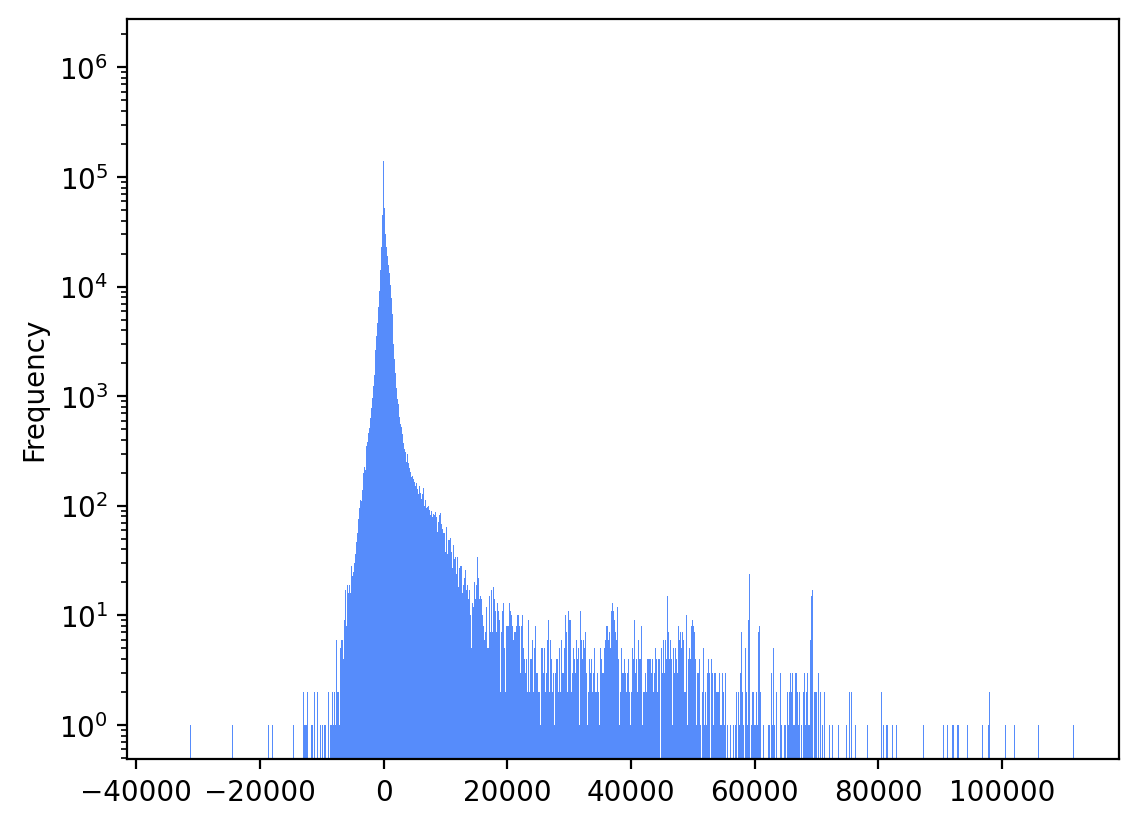

In [273]:
base_x_policy_base_trips["travel_time_diff"].plot.hist(bins=1000, log=True)

In [274]:
# print statistics of travel_time_diff
def print_travel_time_diff_stats(df, label):
    print(f"Statistics for {label}:")
    print(df["travel_time_diff"].describe())
    print(f"Share of trips with travel time increase: {(df['travel_time_diff'] > 0).mean():.2%}")
    print(f"Share of trips with travel time decrease: {(df['travel_time_diff'] < 0).mean():.2%}")
    print(f"Share of trips with travel time change > 5 min: {(df['travel_time_diff'] > 5*60).mean():.2%}")
    print(f"Share of trips with travel time change > 10 min: {(df['travel_time_diff'] > 10*60).mean():.2%}")
    print(f"Share of trips with travel time change > 15 min: {(df['travel_time_diff'] > 15*60).mean():.2%}")

print_travel_time_diff_stats(base_x_policy_base_trips, "Base vs Policy")
print("\n==== \n")
(print_travel_time_diff_stats(base_x_policy_deparking_trips, "Base vs Policy with deparking"))

Statistics for Base vs Policy:
count    1.818412e+06
mean     8.808338e+01
std      1.358492e+03
min     -3.414600e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.116870e+05
Name: travel_time_diff, dtype: float64
Share of trips with travel time increase: 21.32%
Share of trips with travel time decrease: 18.52%
Share of trips with travel time change > 5 min: 7.90%
Share of trips with travel time change > 10 min: 5.09%
Share of trips with travel time change > 15 min: 3.20%

==== 

Statistics for Base vs Policy with deparking:
count    1.819831e+06
mean     3.061809e+01
std      3.771764e+02
min     -3.128800e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.250000e+04
Name: travel_time_diff, dtype: float64
Share of trips with travel time increase: 21.13%
Share of trips with travel time decrease: 18.83%
Share of trips with travel time change > 5 min: 7.49%
Share of trips with travel time change > 10 min: 4.69%
Share of trips w

In [275]:
import seaborn as sns
# make a matrix of main_mode_base and main_mode_policy. count how many trips fall into each combination of modes. also report the mean travel_time_diff for each combination of modes. create a function that takes a merged dataframe and returns the data frame
def mode_combination_matrix(df):
    mode_matrix = df.groupby(["main_mode_base", "main_mode_policy"]).agg(
        trip_count=("trip_id", "count"),
        mean_travel_time_diff=("travel_time_diff", "mean"),
        sum_travel_time_diff_hr=("travel_time_diff", "sum")
    ).reset_index()
    mode_matrix["trip_count"] /= pct
    mode_matrix["sum_travel_time_diff_hr"] /= 3600
    mode_matrix["sum_travel_time_diff_hr"] /= pct
    return mode_matrix

# create a function that takes the mode combination matrix and plots a heatmap of trip_count and mean_travel_time_diff
def plot_mode_combination_heatmap(mode_matrix, value_col, title, cmap="bwr", center=True):
    pivot_table = mode_matrix.pivot(index="main_mode_base", columns="main_mode_policy", values=value_col)
    # filter out rows where main_mode_base is commercial_goods_car, freight or truck
    exclude = ["commercial_goods_car", "freight", "truck"]
    pivot_table = pivot_table.loc[
        ~pivot_table.index.isin(exclude),
        ~pivot_table.columns.isin(exclude)
    ]
    plt.figure(figsize=(10, 8))
    if center:
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=",.0f",      # thousands separators, no decimals
            cmap=cmap,
            center=0
        )
    else:
        sns.heatmap(
            pivot_table,
            annot=True,
            fmt=",.0f",      # thousands separators, no decimals
            cmap=cmap
        )
    plt.title(title)
    plt.show()

In [276]:
mode_matrix_base_policy = mode_combination_matrix(base_x_policy_base_trips)
mode_matrix_base_deparking = mode_combination_matrix(base_x_policy_deparking_trips)

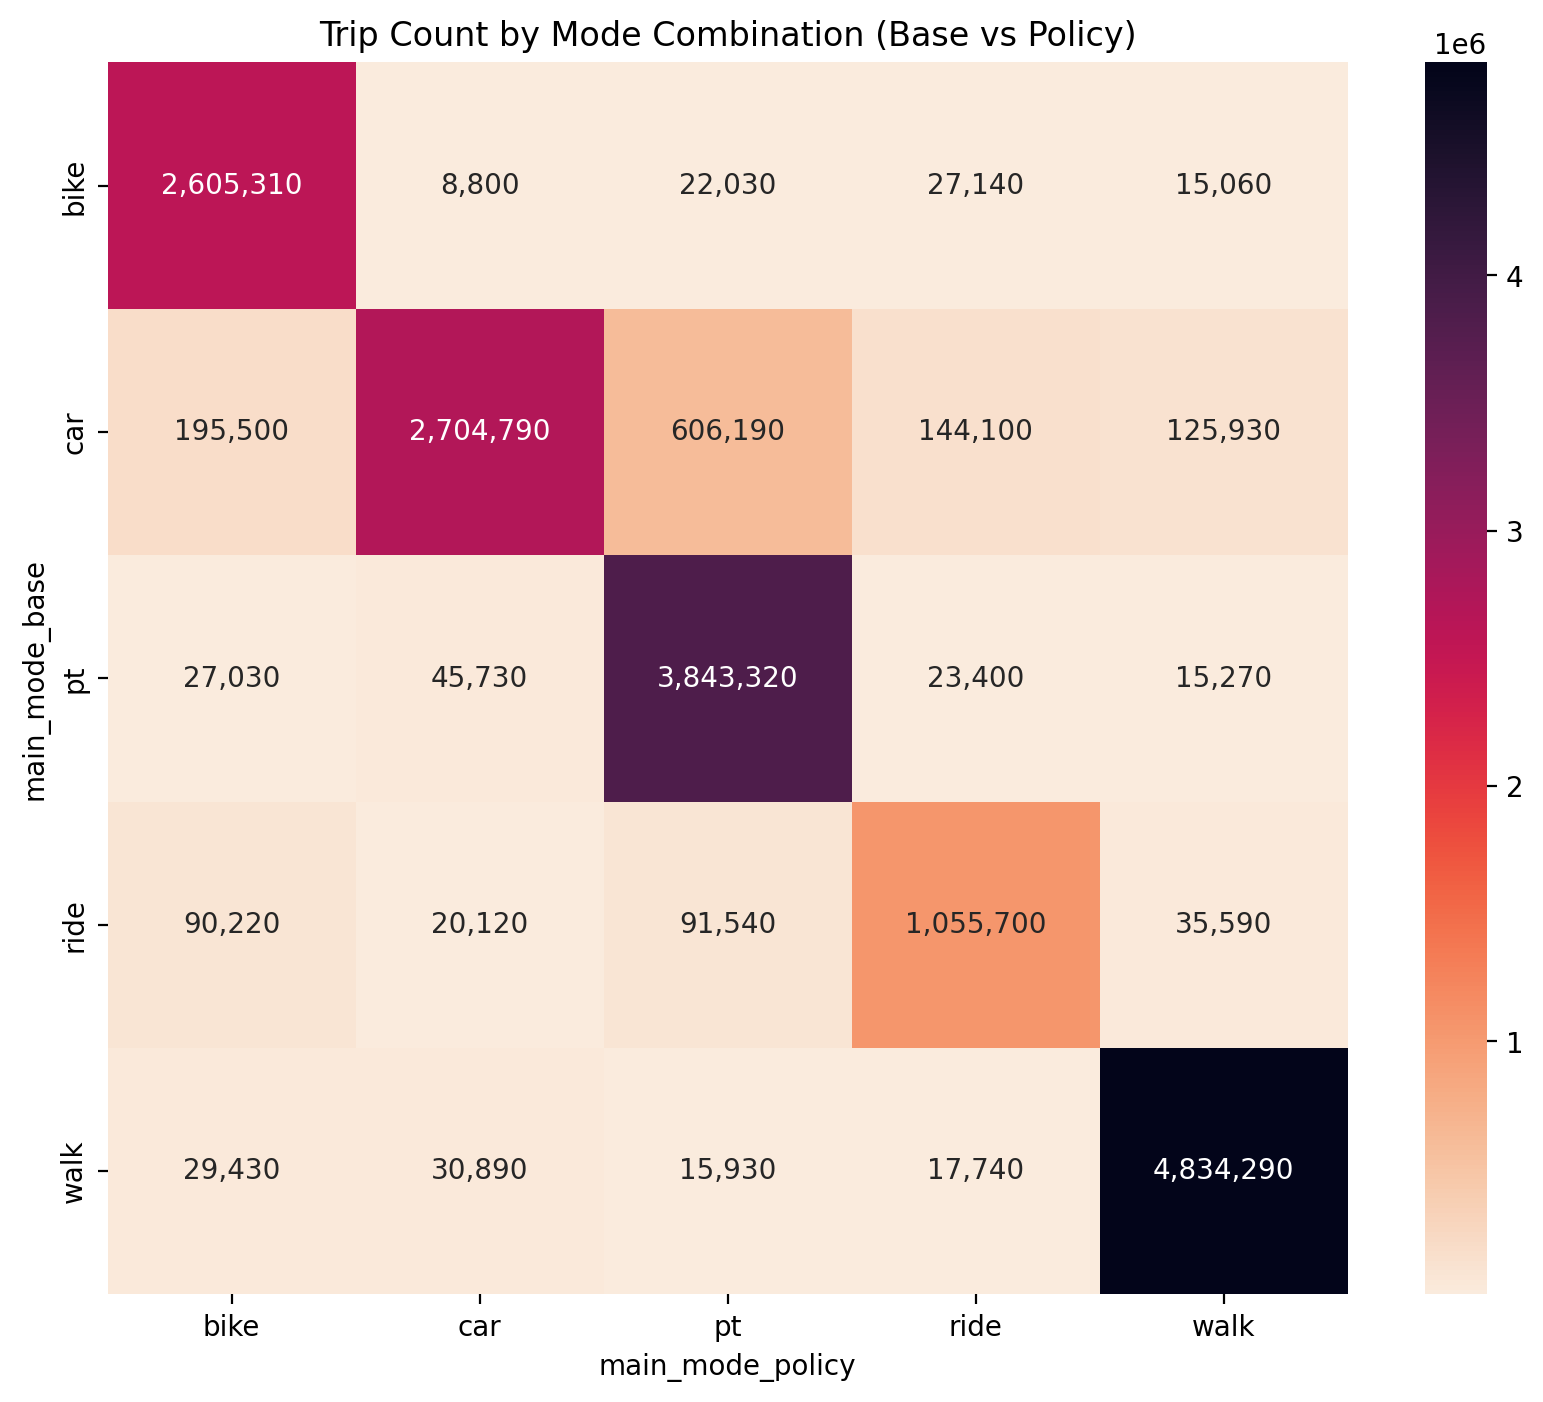

In [277]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "trip_count", "Trip Count by Mode Combination (Base vs Policy)", cmap="rocket_r", center=False)

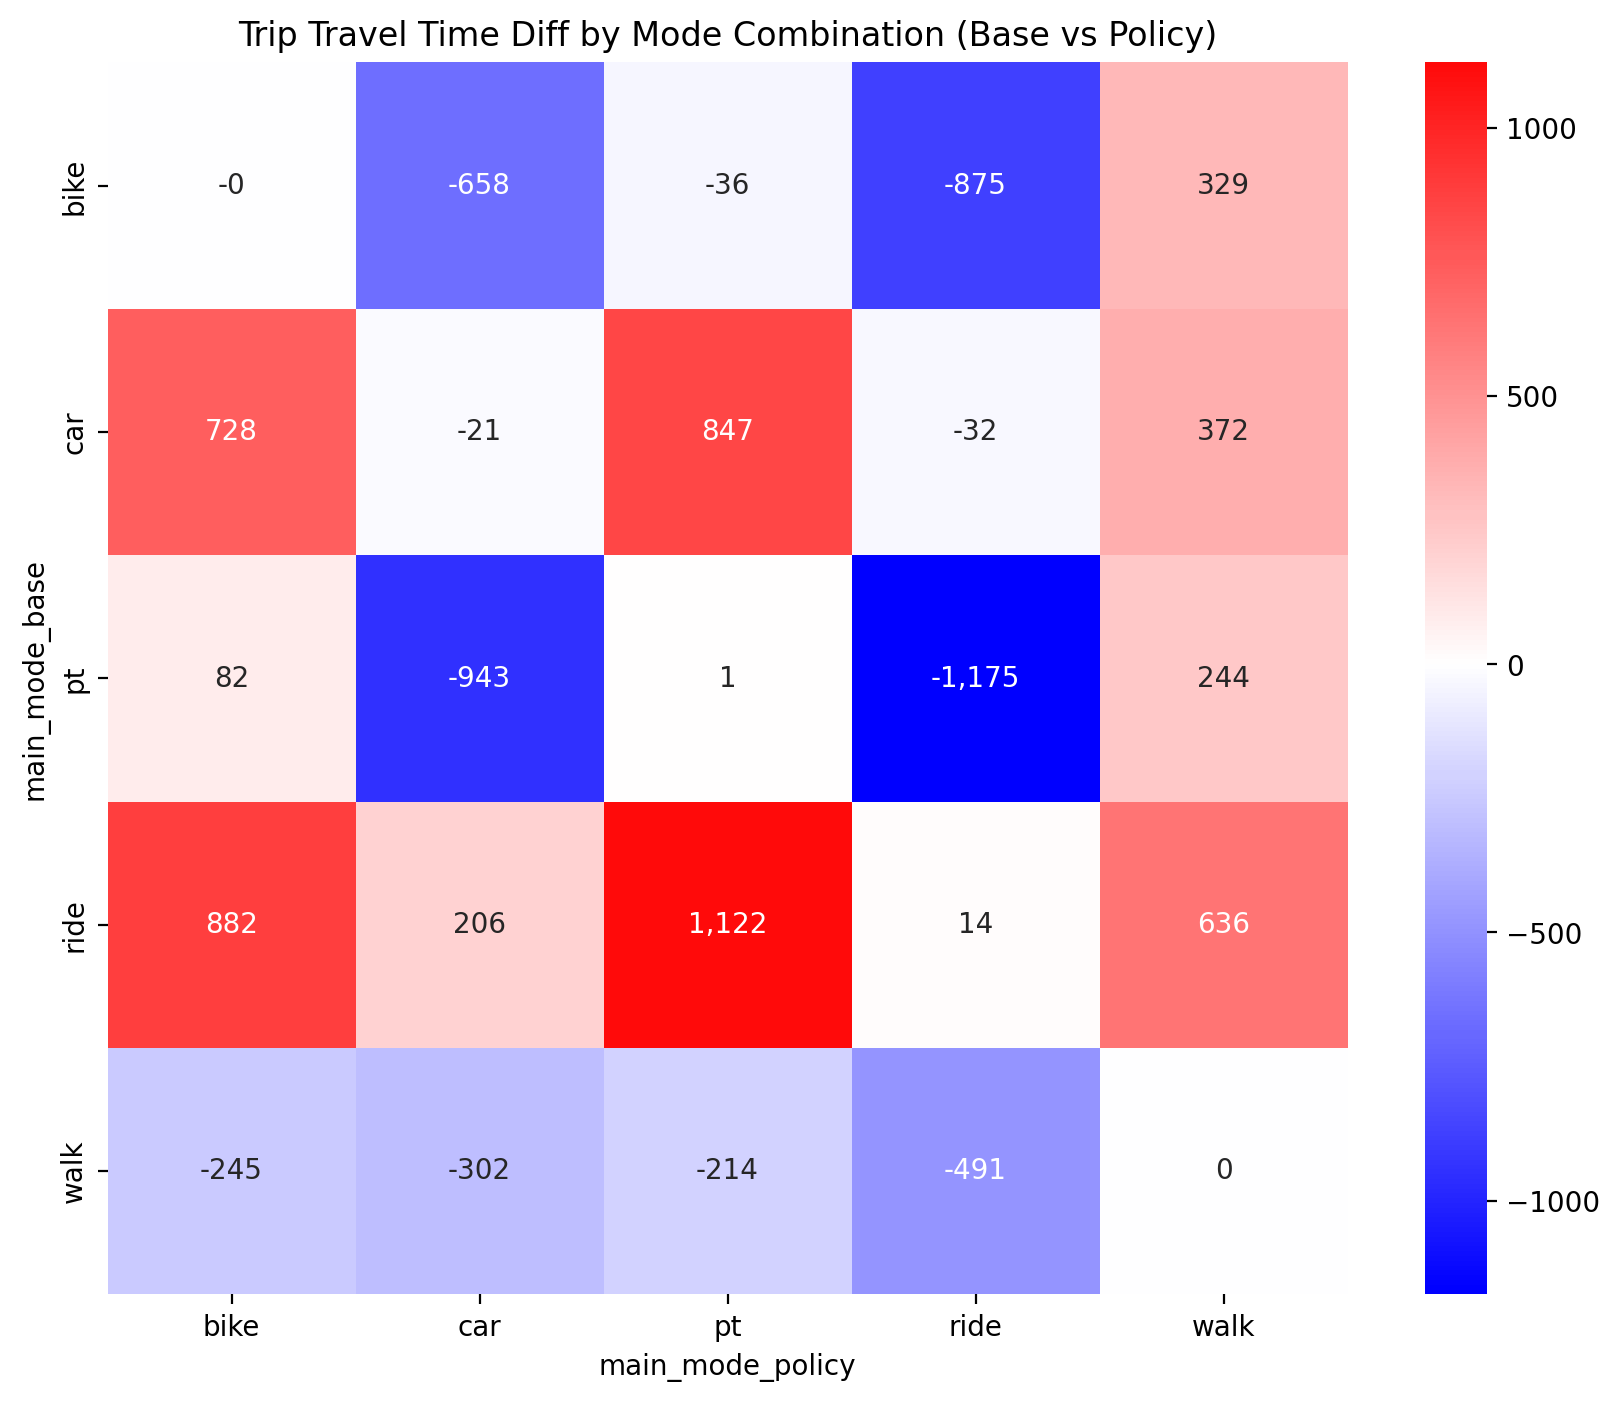

In [278]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "mean_travel_time_diff", "Trip Travel Time Diff by Mode Combination (Base vs Policy)")


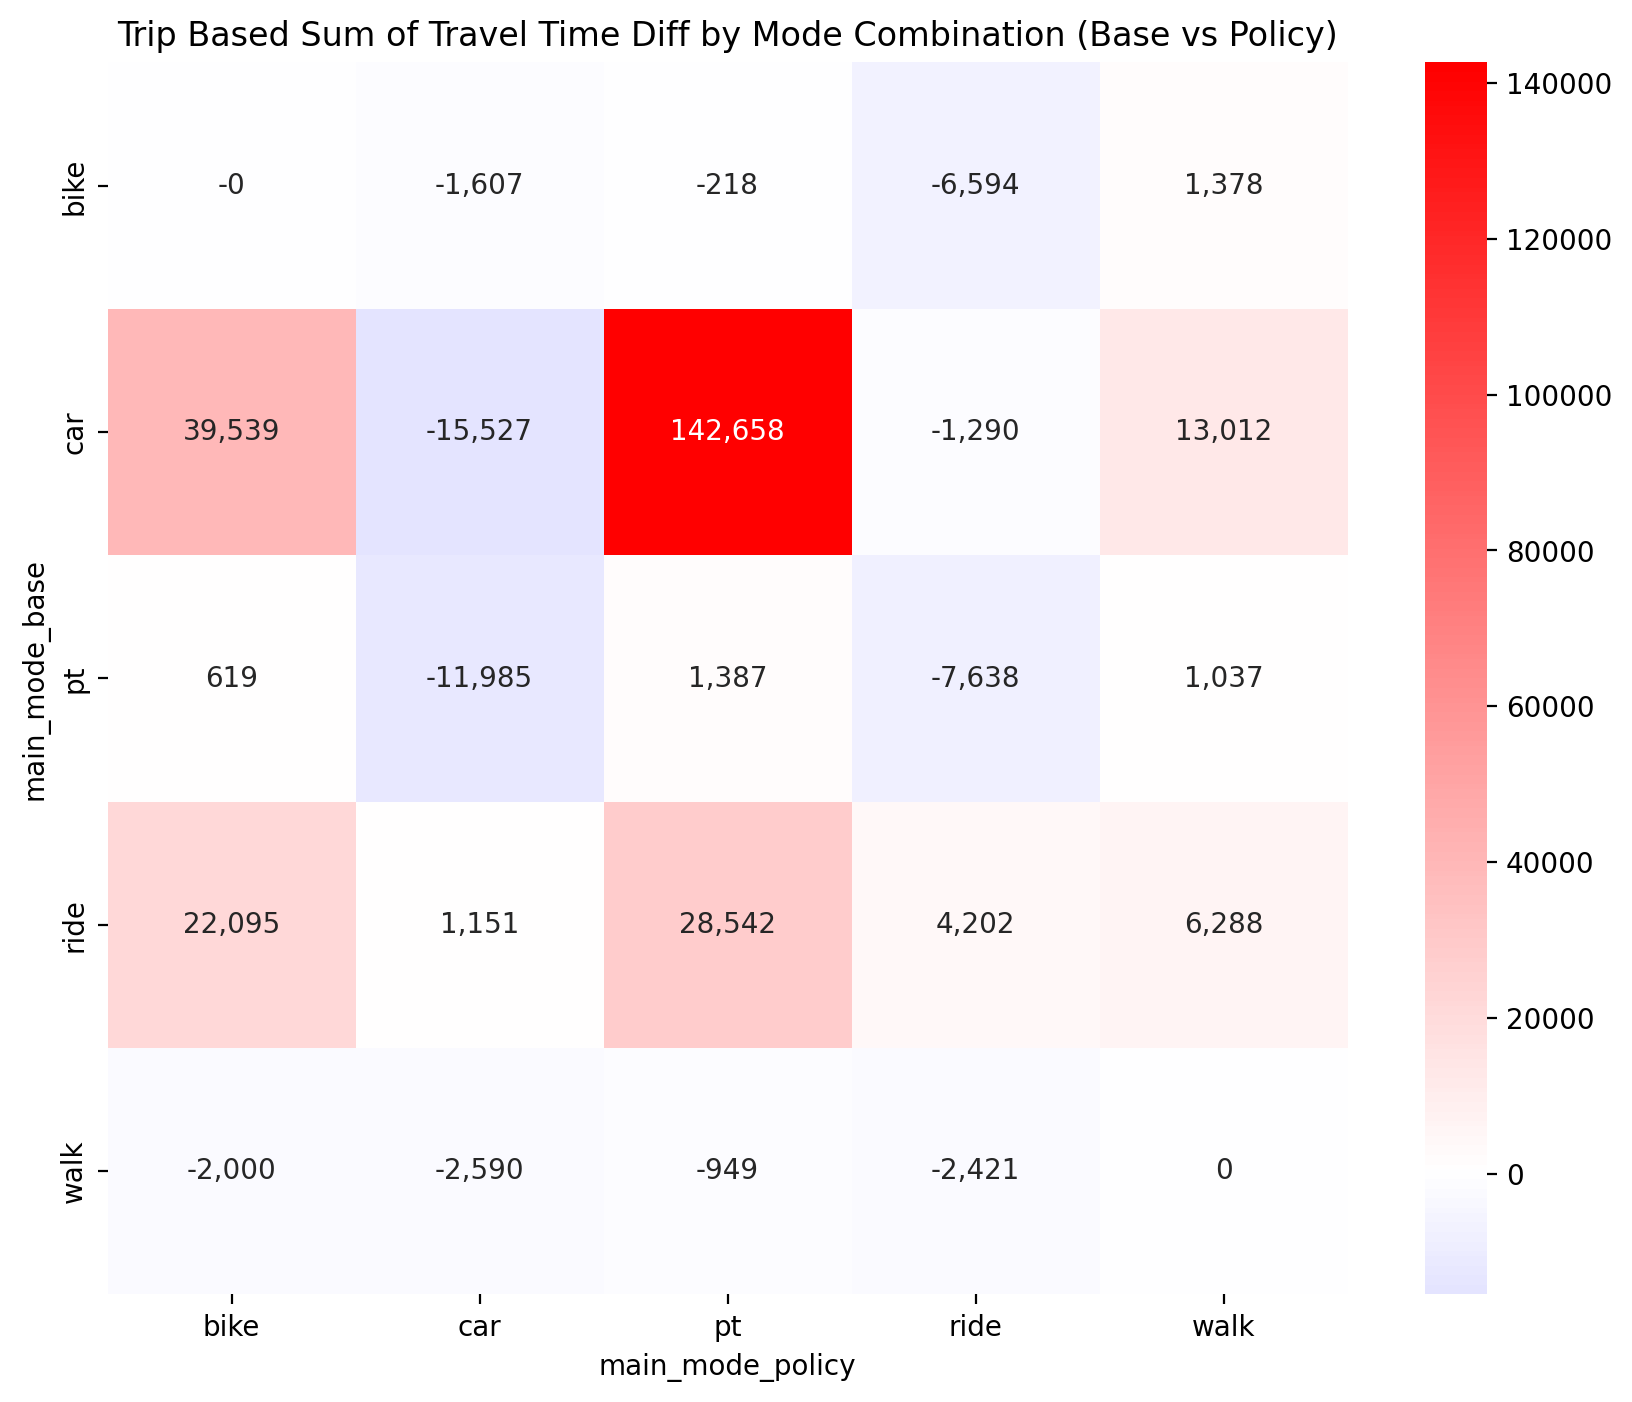

In [279]:
plot_mode_combination_heatmap(mode_matrix_base_deparking, "sum_travel_time_diff_hr", "Trip Based Sum of Travel Time Diff by Mode Combination (Base vs Policy)")


In [280]:
# make a facet heatmap plot. use bezirke and umweltzone to cluster trips.

# 1) merge base_persons with base_x_policy_base_trips and base_x_policy_deparking_trips on person_id, keep the home_x and home_y columns from base_persons, keep all columns from the trips dataframes, add suffixes to distinguish between the two merges
def merge_persons_trips(persons_df, trips_df):
    merged = trips_df.merge(
        persons_df[["person", "home_x", "home_y"]],
        left_on="person_base",
        right_on="person",
        how="left",
    )
    return merged

base_x_policy_base_trips_home = merge_persons_trips(base_persons, base_x_policy_base_trips)
base_x_policy_deparking_trips_home = merge_persons_trips(base_persons, base_x_policy_deparking_trips)

# 2) use the bezirke and umweltzone dfs to cluster the persons: if home in umweltzone, cluster "inner", if not in umwelt, but in bezirke, cluster as "outer", else "brandenburg"
def cluster_persons_by_location(df, bezirke_gdf, umweltzone_gdf):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["home_x"], df["home_y"]),
        crs="EPSG:25832"
    )
    # check if points are in umweltzone
    gdf["cluster"] = "Brandenburg"
    gdf.loc[gdf.geometry.within(bezirke_gdf.to_crs("EPSG:25832").union_all()), "cluster"] = "Outer Ring"
    gdf.loc[gdf.geometry.within(umweltzone_gdf.to_crs("EPSG:25832").union_all()), "cluster"] = "Inner Ring"

    order = ["Brandenburg", "Outer Ring", "Inner Ring"]

    gdf["cluster"] = pd.Categorical(
        gdf["cluster"],
        categories=order,
        ordered=True
    )

    return gdf

In [281]:
base_x_policy_base_trips_home = cluster_persons_by_location(base_x_policy_base_trips_home, bezirke, umweltzone)
base_x_policy_deparking_trips_home = cluster_persons_by_location(base_x_policy_deparking_trips_home, bezirke, umweltzone)

In [282]:
base_x_policy_base_trips_home["cluster"].describe()

count        1818412
unique             3
top       Outer Ring
freq          899122
Name: cluster, dtype: object

In [325]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def mode_combination_matrix_cluster(df):
    mode_matrix = (
        df.groupby(
            ["cluster", "main_mode_base", "main_mode_policy"],
            as_index=False
        )
        .agg(
            trip_count=("trip_id", "count"),
            mean_travel_time_diff_min=("travel_time_diff", "mean"),
            median_travel_time_diff_min=("travel_time_diff", "median"),
            sum_travel_time_diff_hr=("travel_time_diff", "sum")
        )
    )
    mode_matrix["mean_travel_time_diff_min"] /= 60
    mode_matrix["median_travel_time_diff_min"] /= 60
    mode_matrix["sum_travel_time_diff_hr"] /= 3600
    mode_matrix["sum_travel_time_diff_hr"] /= pct
    mode_matrix["trip_count"] /= pct
    return mode_matrix

def plot_mode_combination_heatmap_facet(
        mode_matrix,
        value_col,
        title,
        cluster_col="cluster",
        cmap="bwr",
        center=True
):
    exclude = ["commercial_goods_car", "freight", "truck"]

    plot_df = mode_matrix[
        ~mode_matrix["main_mode_base"].isin(exclude)
        & ~mode_matrix["main_mode_policy"].isin(exclude)
        ].copy()

    clusters = sorted(plot_df[cluster_col].dropna().unique())
    n_clusters = len(clusters)

    if n_clusters == 0:
        raise ValueError("No clusters found after filtering.")

    ncols = 3 if n_clusters == 3 else 2
    nrows = math.ceil(n_clusters / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5.5 * ncols, 5 * nrows),
        sharey=False,
        squeeze=False
    )

    vmin = plot_df[value_col].min()
    vmax = plot_df[value_col].max()

    for i, cluster in enumerate(clusters):
        row_idx = i // ncols
        col_idx = i % ncols
        ax = axes[row_idx, col_idx]

        subset = plot_df[plot_df[cluster_col] == cluster]

        pivot_table = subset.pivot(
            index="main_mode_base",
            columns="main_mode_policy",
            values=value_col
        )

        labels = pivot_table.apply(
            lambda col: col.map(
                lambda x: f"{x:,.0f}" if pd.notna(x) else ""
            )
        )

        sns.heatmap(
            pivot_table,
            square=True,
            annot=labels,
            fmt="",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            center=0 if center else None,
            ax=ax,
            cbar=(i == n_clusters - 1)
        )

        ax.set_title(f"Home: {cluster}")

        if row_idx == nrows - 1:
            ax.set_xlabel("Main Mode Policy Deparking")
        else:
            ax.set_xlabel("")

        if col_idx == 0:
            ax.set_ylabel("Main Mode Base")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", left=False, labelleft=False)

    # Hide unused axes in incomplete final row
    for i in range(n_clusters, nrows * ncols):
        row_idx = i // ncols
        col_idx = i % ncols
        axes[row_idx, col_idx].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

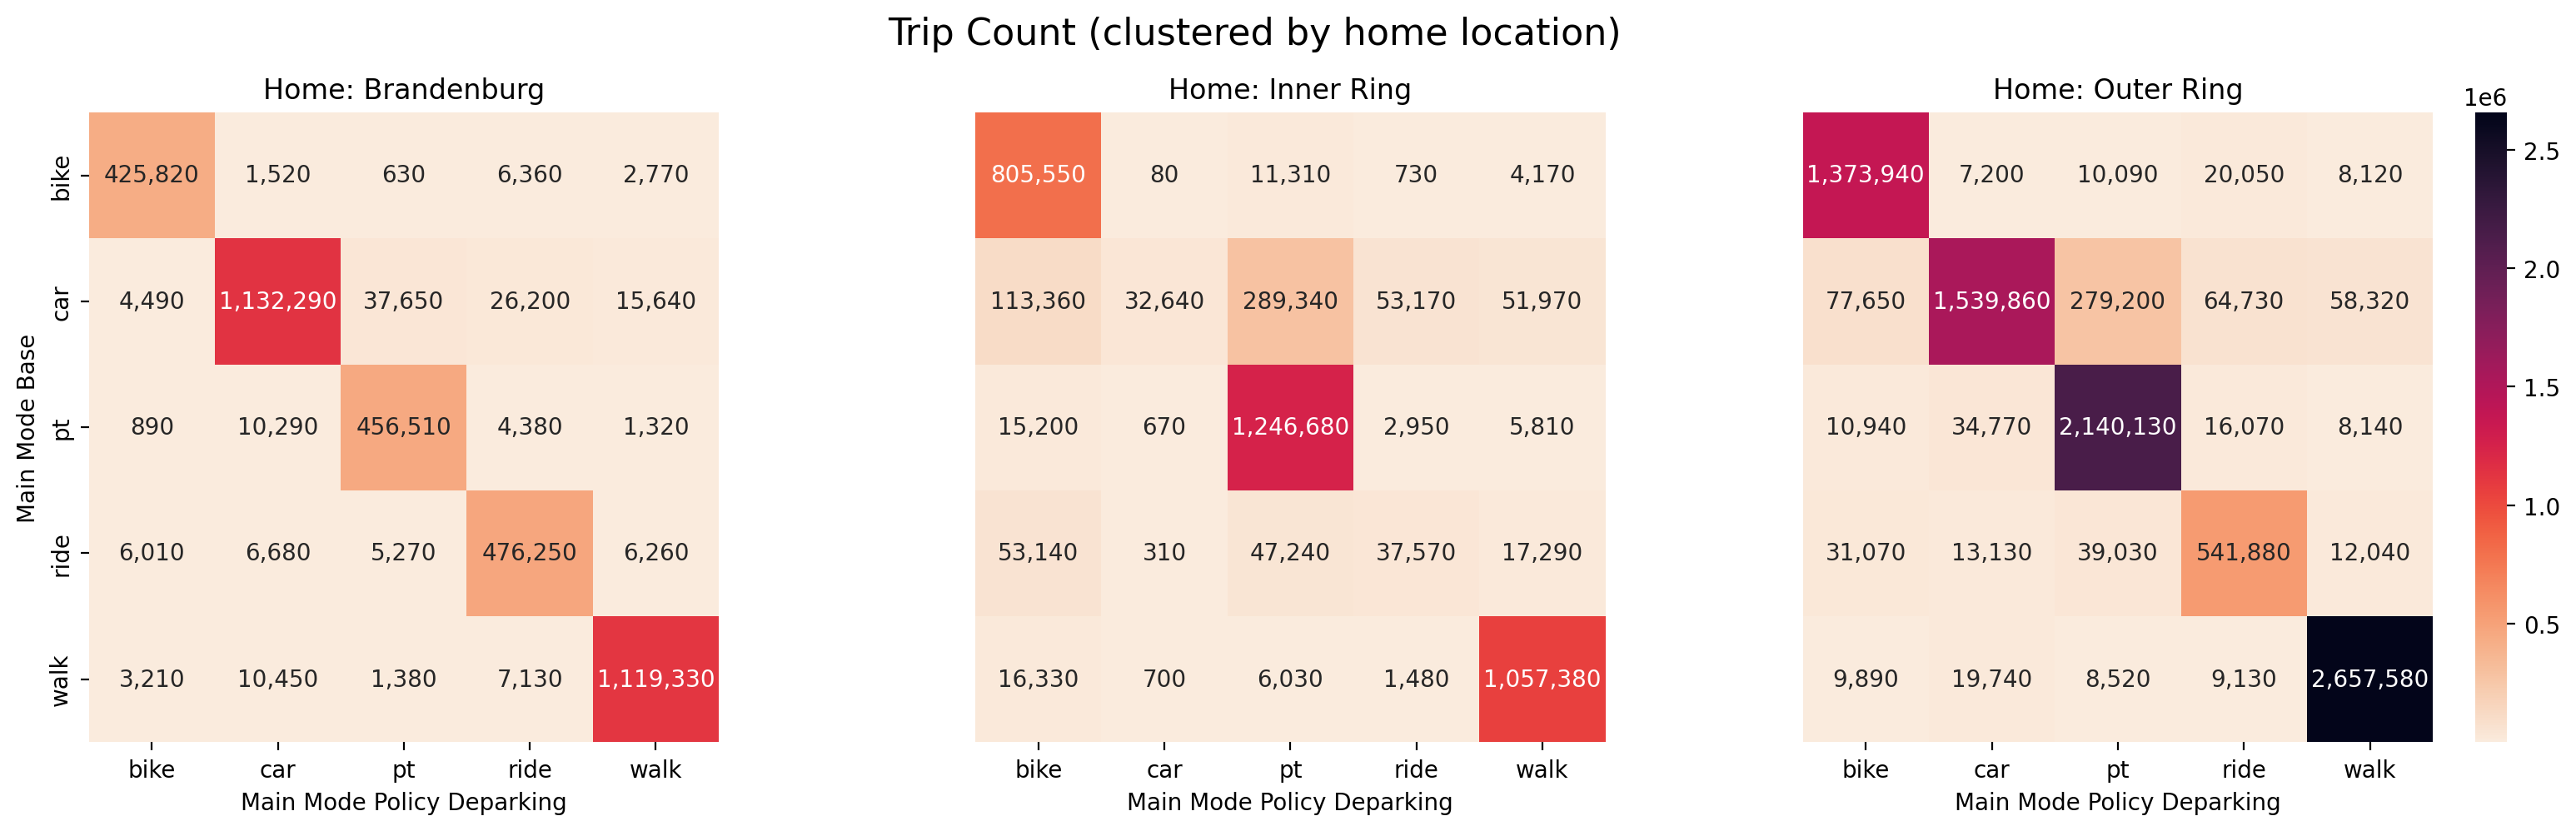

In [285]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home), "trip_count", "Trip Count (clustered by home location)", cmap="rocket_r", center=False)

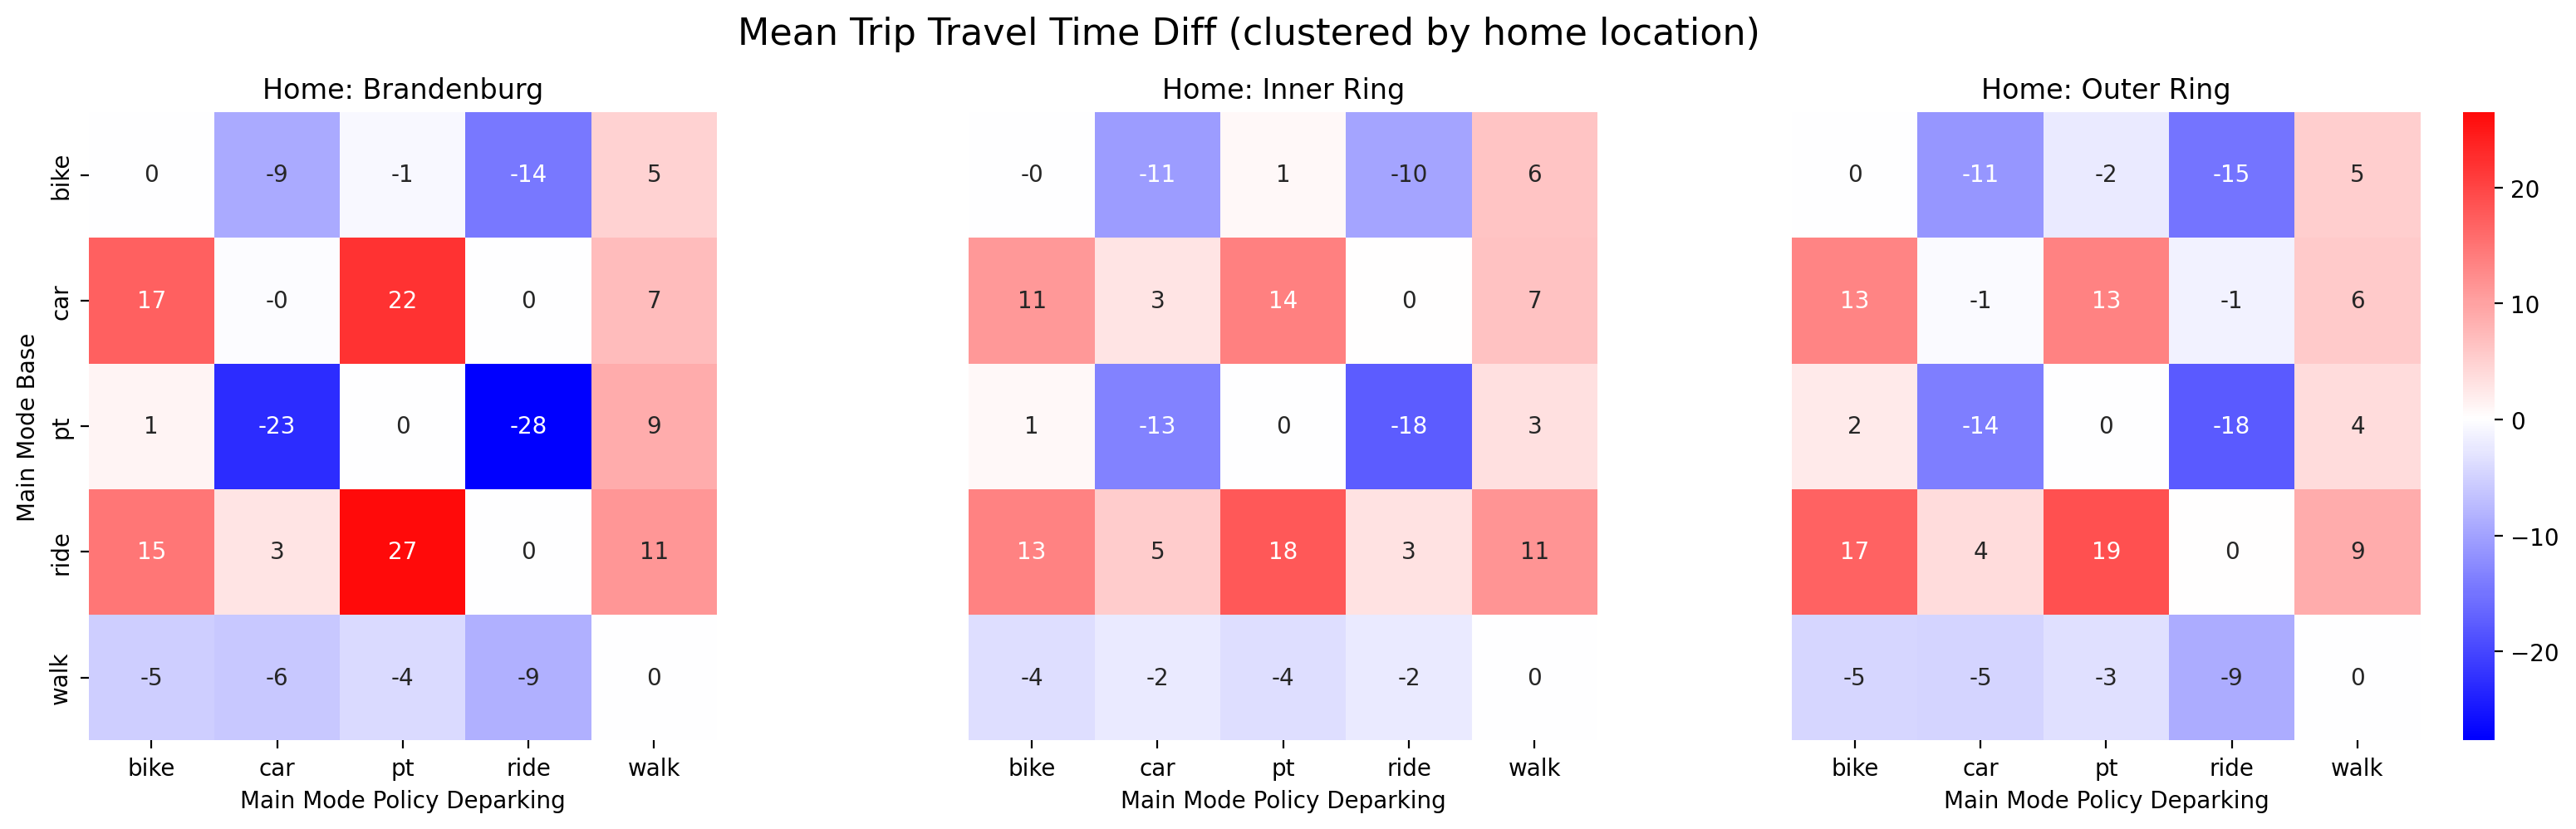

In [286]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home),
                                    "mean_travel_time_diff_min", "Mean Trip Travel Time Diff (clustered by home location)")

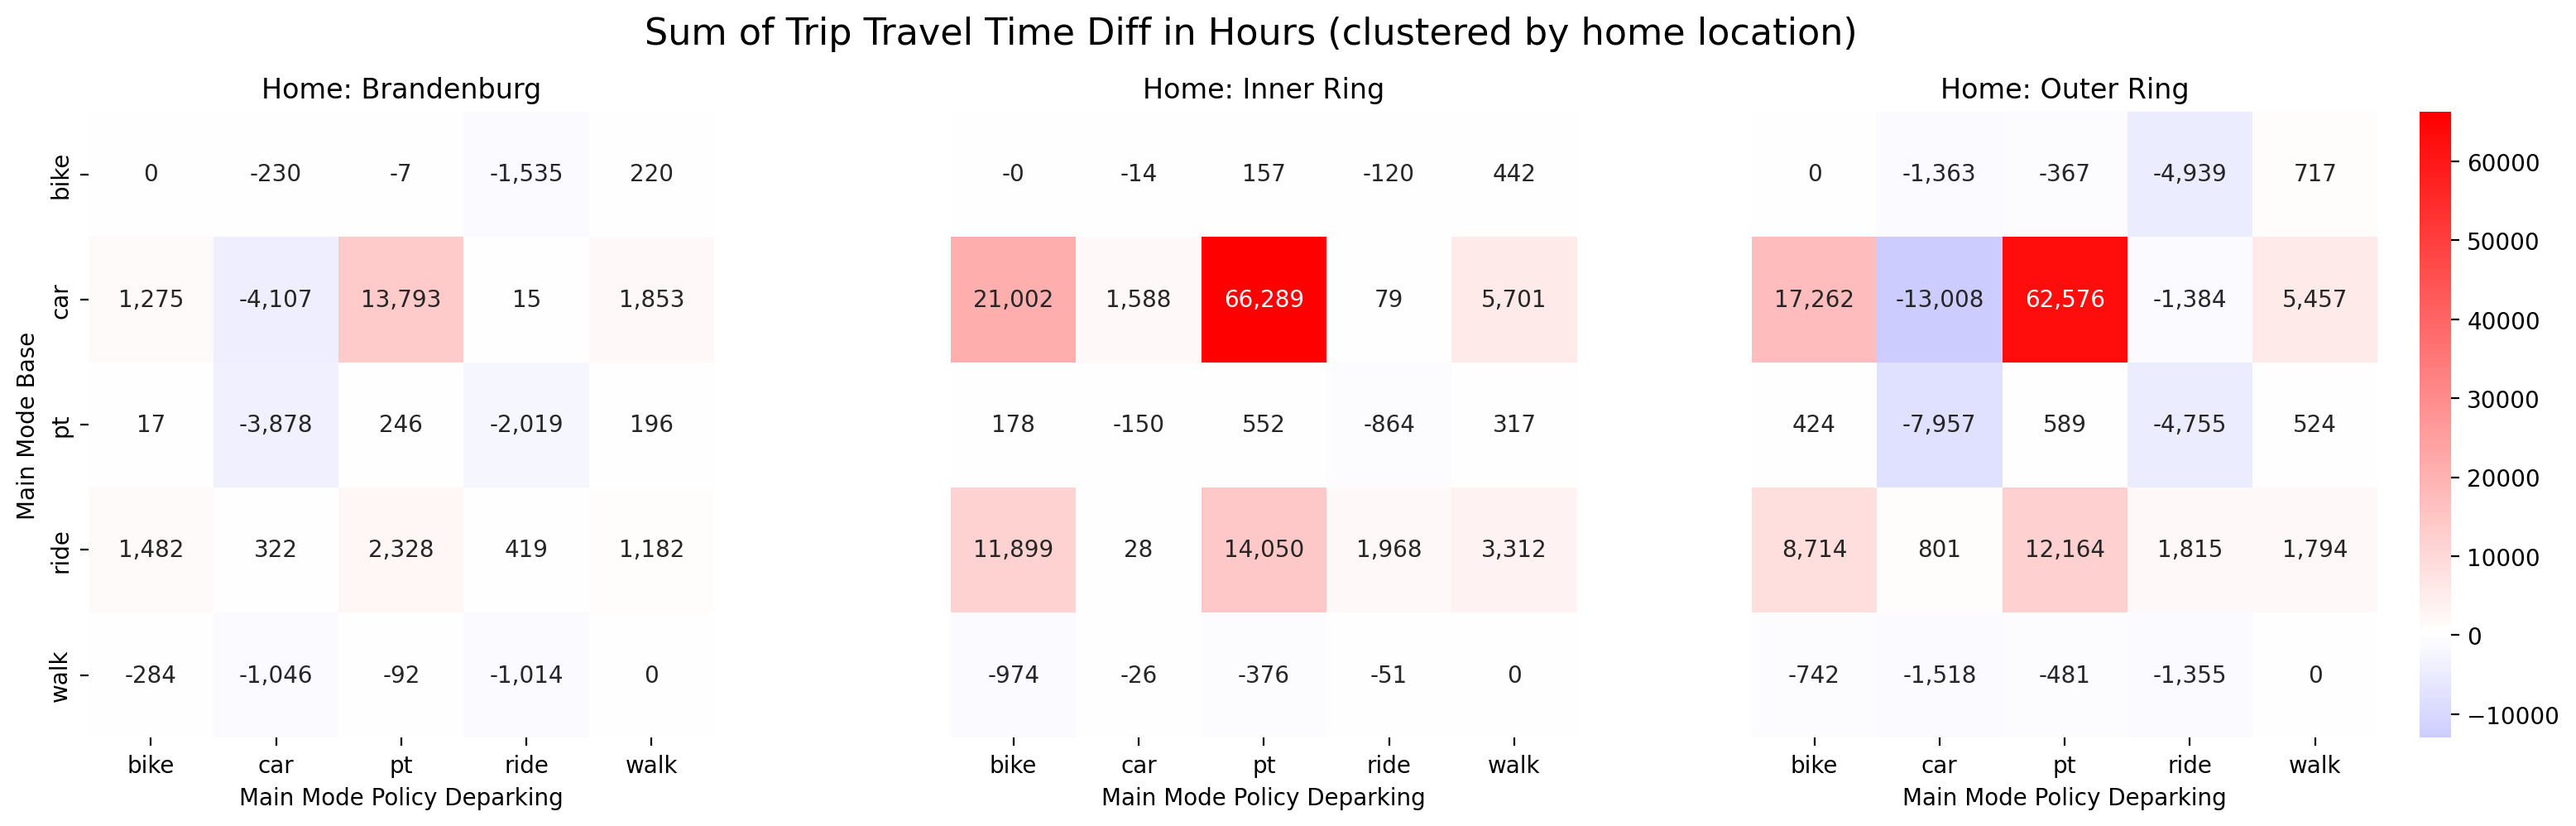

In [287]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_cluster(base_x_policy_deparking_trips_home),
                                    "sum_travel_time_diff_hr", "Sum of Trip Travel Time Diff in Hours (clustered by home location)")

In [292]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_mode_combination_bubble_facet(
        mode_matrix,
        title,
        color_col="mean_travel_time_diff_min",
        size_col="trip_count",
        cluster_col="cluster",
        cluster_label="Home",
        cmap="bwr",
        center=True,
        size_scale=1800,
):
    exclude = ["commercial_goods_car", "freight", "truck"]

    plot_df = mode_matrix[
        ~mode_matrix["main_mode_base"].isin(exclude)
        & ~mode_matrix["main_mode_policy"].isin(exclude)
        ].copy()

    clusters = sorted(plot_df[cluster_col].dropna().unique())
    n_clusters = len(clusters)

    if n_clusters == 0:
        raise ValueError("No clusters found after filtering.")

    modes = sorted(
        set(plot_df["main_mode_base"].dropna())
        | set(plot_df["main_mode_policy"].dropna())
    )

    x_map = {mode: i for i, mode in enumerate(modes)}
    y_map = {mode: i for i, mode in enumerate(modes)}

    plot_df["x"] = plot_df["main_mode_policy"].map(x_map)
    plot_df["y"] = plot_df["main_mode_base"].map(y_map)

    if center:
        max_abs = np.nanmax(np.abs(plot_df[color_col]))
        norm = mpl.colors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    else:
        norm = mpl.colors.Normalize(
            vmin=plot_df[color_col].min(),
            vmax=plot_df[color_col].max()
        )

    max_size = plot_df[size_col].max()
    plot_df["marker_size"] = plot_df[size_col] / max_size * size_scale

    ncols = 3 if n_clusters == 3 else 2
    nrows = math.ceil(n_clusters / ncols)

    fig_width = 5.5 * ncols + 0.6
    fig_height = 5 * nrows

    fig = plt.figure(figsize=(fig_width, fig_height))

    gs = fig.add_gridspec(
        nrows,
        ncols + 1,
        width_ratios=[1] * ncols + [0.04],
        wspace=0.12,
        hspace=0.35
    )

    axes = []
    for idx in range(n_clusters):
        row = idx // ncols
        col = idx % ncols
        axes.append(fig.add_subplot(gs[row, col]))

    cbar_ax = fig.add_subplot(gs[:, ncols])

    scatter = None

    for i, (ax, cluster) in enumerate(zip(axes, clusters)):
        subset = plot_df[plot_df[cluster_col] == cluster]

        scatter = ax.scatter(
            subset["x"],
            subset["y"],
            s=subset["marker_size"],
            c=subset[color_col],
            cmap=cmap,
            norm=norm,
            edgecolors="black",
            linewidths=0.6
        )

        for _, row in subset.iterrows():
            label = f"{row[color_col]:,.1f}"

            if row["marker_size"] >= 300:
                ax.text(
                    row["x"],
                    row["y"],
                    label,
                    ha="center",
                    va="center",
                    fontsize=9
                )
            else:
                ax.text(
                    row["x"],
                    row["y"] + 0.18,
                    label,
                    ha="center",
                    va="top",
                    fontsize=8
                )

        ax.set_title(f"{cluster_label}: {cluster}")

        ax.set_xticks(range(len(modes)))
        ax.set_xticklabels(modes, rotation=45, ha="right")

        ax.set_yticks(range(len(modes)))
        ax.set_yticklabels(modes)

        ax.set_xlim(-0.5, len(modes) - 0.5)
        ax.set_ylim(len(modes) - 0.5, -0.5)

        row_idx = i // ncols
        col_idx = i % ncols

        if row_idx == nrows - 1:
            ax.set_xlabel("Main Mode Policy Deparking")
        else:
            ax.set_xlabel("")

        if col_idx == 0:
            ax.set_ylabel("Main Mode Base")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", left=False, labelleft=False)

        ax.grid(True, linewidth=0.5, alpha=0.35)

    # Hide unused slots if the final row is incomplete
    for idx in range(n_clusters, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        empty_ax = fig.add_subplot(gs[row, col])
        empty_ax.axis("off")

    cbar = fig.colorbar(scatter, cax=cbar_ax)
    cbar.set_label("Mean Travel Time Difference in Minutes")

    fig.suptitle(title, fontsize=16)
    plt.savefig(
        "./plots/" + title + ".pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.show()

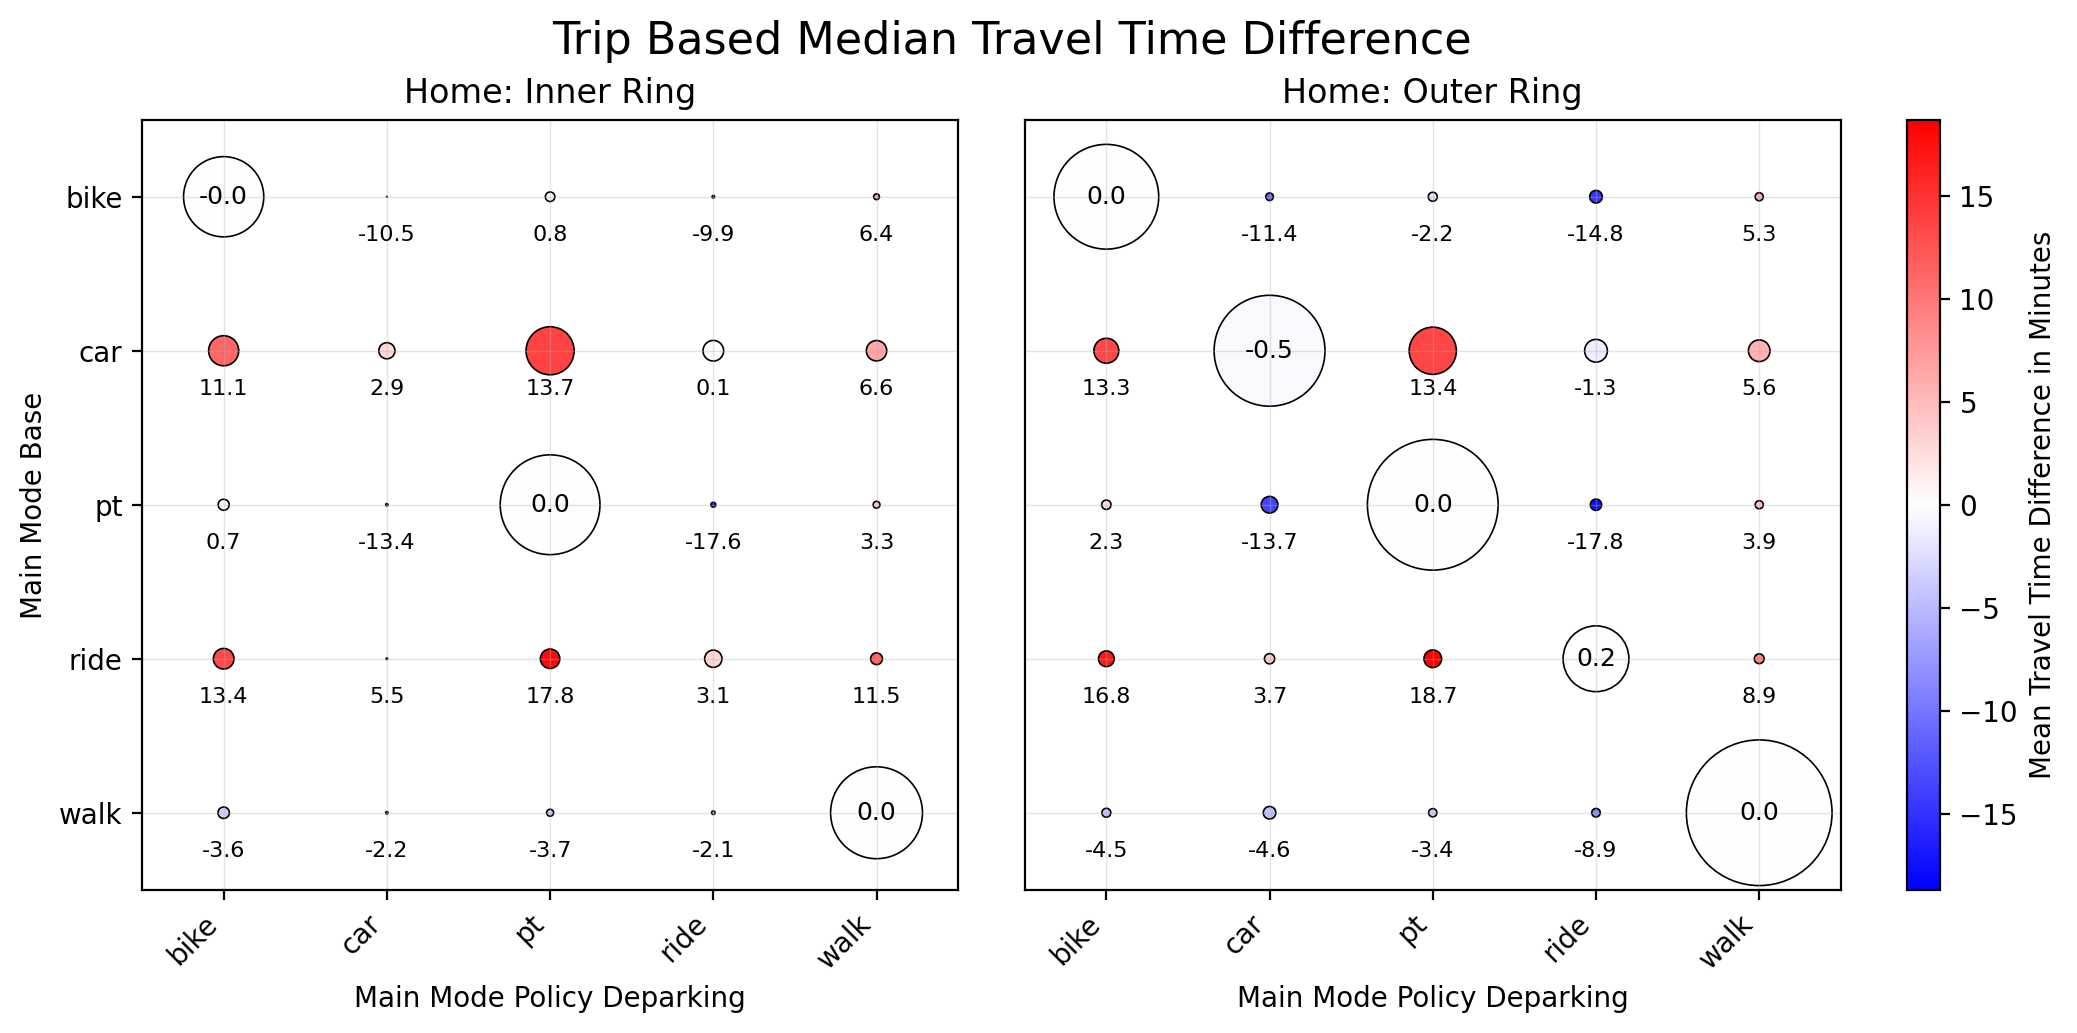

In [329]:
cluster = mode_combination_matrix_cluster(base_x_policy_deparking_trips_home)
cluster = cluster[cluster["cluster"]!="Brandenburg"]
plot_mode_combination_bubble_facet(cluster, "Trip Based Median Travel Time Difference", size_scale=2750)

# Mode Travel Times (Aggregated)
ss

In [242]:
base_x_policy_deparking_trips_home.columns

Index(['person_base', 'trip_number_base', 'trip_id', 'dep_time_base',
       'trav_time_base', 'wait_time_base', 'traveled_distance_base',
       'euclidean_distance_base', 'main_mode_base',
       'longest_distance_mode_base', 'modes_base', 'start_activity_type_base',
       'end_activity_type_base', 'start_facility_id_base', 'start_link_base',
       'start_x_base', 'start_y_base', 'end_facility_id_base', 'end_link_base',
       'end_x_base', 'end_y_base', 'first_pt_boarding_stop_base',
       'last_pt_egress_stop_base', 'person_policy', 'trip_number_policy',
       'dep_time_policy', 'trav_time_policy', 'wait_time_policy',
       'traveled_distance_policy', 'euclidean_distance_policy',
       'main_mode_policy', 'longest_distance_mode_policy', 'modes_policy',
       'start_activity_type_policy', 'end_activity_type_policy',
       'start_facility_id_policy', 'start_link_policy', 'start_x_policy',
       'start_y_policy', 'end_facility_id_policy', 'end_link_policy',
       'end_x_poli

In [243]:
def print_tt_distance_stats(df):


    result = (
        df.groupby(["main_mode_base", "cluster"])
        .agg(
            tt_base=("trav_time_base", "mean"),
            tt_policy=("trav_time_policy", "mean"),
            # dist_base=("traveled_distance_base", "mean"),
            # dist_policy=("traveled_distance_policy", "mean"),
        )
        .reset_index()
        .rename(columns={"main_mode_base": "mode"})
    )

    result["mode"] = result["mode"].replace(
        {"commercial_goods_car": "commercial"}
    )
    result["cluster"] = result["cluster"].cat.rename_categories(
        {
            "Brandenburg": "BRA",
            "Outer Ring": "OR",
            "Inner Ring": "IR",
        }
    )

    result["tt_base"] /= 60
    result["tt_policy"] /= 60
    # result["dist_base"] /= 1000
    # result["dist_policy"] /= 1000

    result["tt_delta"] = result["tt_policy"] - result["tt_base"]
    # result["dist_delta"] = result["dist_policy"] - result["dist_base"]

    mode_order = [
        "bike",
        "car",
        "pt",
        "ride",
        "walk",
        "commercial",
        "freight",
        "truck",
    ]
    result = result[~result["mode"].isin(["commercial", "freight", "truck"])]
    result["mode"] = pd.Categorical(
        result["mode"],
        categories=mode_order,
        ordered=True,
    )

    result = result[
        [
            "mode",
            "cluster",
            "tt_base",
            "tt_policy",
            "tt_delta",
            # "dist_base",
            # "dist_policy",
            # "dist_delta",
        ]
    ]

    result = result.sort_values(["mode", "cluster"])

    numeric_cols = result.select_dtypes(include="number").columns
    result[numeric_cols] = result[numeric_cols].round(1)

    result = result.rename(
        columns={
            "mode": "Mode",
            "cluster": "Home",
            "tt_base": "TT Base",
            "tt_policy": "TT Policy",
            "tt_delta": r"TT $\Delta$",
            # "dist_base": "Base",
            # "dist_policy": "Policy",
            # "dist_delta": r"$\Delta$",
        }
    )

    # result.columns = pd.MultiIndex.from_tuples([
    #     ("", "Mode"),
    #     ("", "Home"),
    #     ("TT [min]", "Base"),
    #     ("TT [min]", "Policy"),
    #     ("TT [min]", r"$\Delta$"),
    #     # ("Dist [km]", "Base"),
    #     # ("Dist [km]", "Policy"),
    #     # ("Dist [km]", r"$\Delta$"),
    # ])

    print(
        result.to_latex(
            index=False,
            float_format="%.1f",
            escape=False,
            # multicolumn=True,
            # multicolumn_format="c",
        )
    )

In [244]:
print_tt_distance_stats(base_x_policy_deparking_trips_home)

\begin{tabular}{llrrr}
\toprule
Mode & Home & TT Base & TT Policy & TT $\Delta$ \\
\midrule
bike & BRA & 22.7 & 22.5 & -0.2 \\
bike & OR & 24.2 & 24.0 & -0.2 \\
bike & IR & 21.9 & 21.9 & 0.0 \\
car & BRA & 30.3 & 30.8 & 0.5 \\
car & OR & 20.5 & 22.5 & 2.0 \\
car & IR & 22.2 & 32.7 & 10.5 \\
pt & BRA & 67.3 & 66.7 & -0.6 \\
pt & OR & 35.7 & 35.4 & -0.3 \\
pt & IR & 32.6 & 32.6 & 0.0 \\
ride & BRA & 14.5 & 15.1 & 0.6 \\
ride & OR & 12.4 & 14.8 & 2.4 \\
ride & IR & 12.8 & 25.0 & 12.2 \\
walk & BRA & 10.8 & 10.7 & -0.1 \\
walk & OR & 7.9 & 7.8 & -0.1 \\
walk & IR & 7.3 & 7.2 & -0.1 \\
\bottomrule
\end{tabular}



In [246]:
import geopandas as gpd


def cluster_trips_by_umweltzone(df, umweltzone, trip_crs="EPSG:25832"):
    umweltzone_geom = umweltzone.geometry.union_all()

    start_points = gpd.GeoSeries(
        gpd.points_from_xy(df["start_x_base"], df["start_y_base"]),
        crs=trip_crs,
    ).to_crs(umweltzone.crs)

    end_points = gpd.GeoSeries(
        gpd.points_from_xy(df["end_x_base"], df["end_y_base"]),
        crs=trip_crs,
    ).to_crs(umweltzone.crs)

    start_inside = start_points.within(umweltzone_geom)
    end_inside = end_points.within(umweltzone_geom)

    df = df.copy()

    df["direction"] = (
            start_inside.map({True: "in", False: "out"})
            + "-to-"
            + end_inside.map({True: "in", False: "out"})
    )

    return df

In [247]:
in_out_trips_deparking = cluster_trips_by_umweltzone(base_x_policy_deparking_trips_home, umweltzone)

In [248]:
def mode_combination_matrix_direction(df):
    mode_matrix = (
        df.groupby(
            ["direction", "main_mode_base", "main_mode_policy"],
            as_index=False
        )
        .agg(
            trip_count=("trip_id", "count"),
            mean_travel_time_diff_min=("travel_time_diff", "mean"),
            sum_travel_time_diff_hr=("travel_time_diff", "sum")
        )
    )
    mode_matrix["sum_travel_time_diff_hr"] /= 3600
    mode_matrix["mean_travel_time_diff_min"] /= 60
    mode_matrix["sum_travel_time_diff_hr"] /= pct
    mode_matrix["trip_count"] /= pct
    return mode_matrix

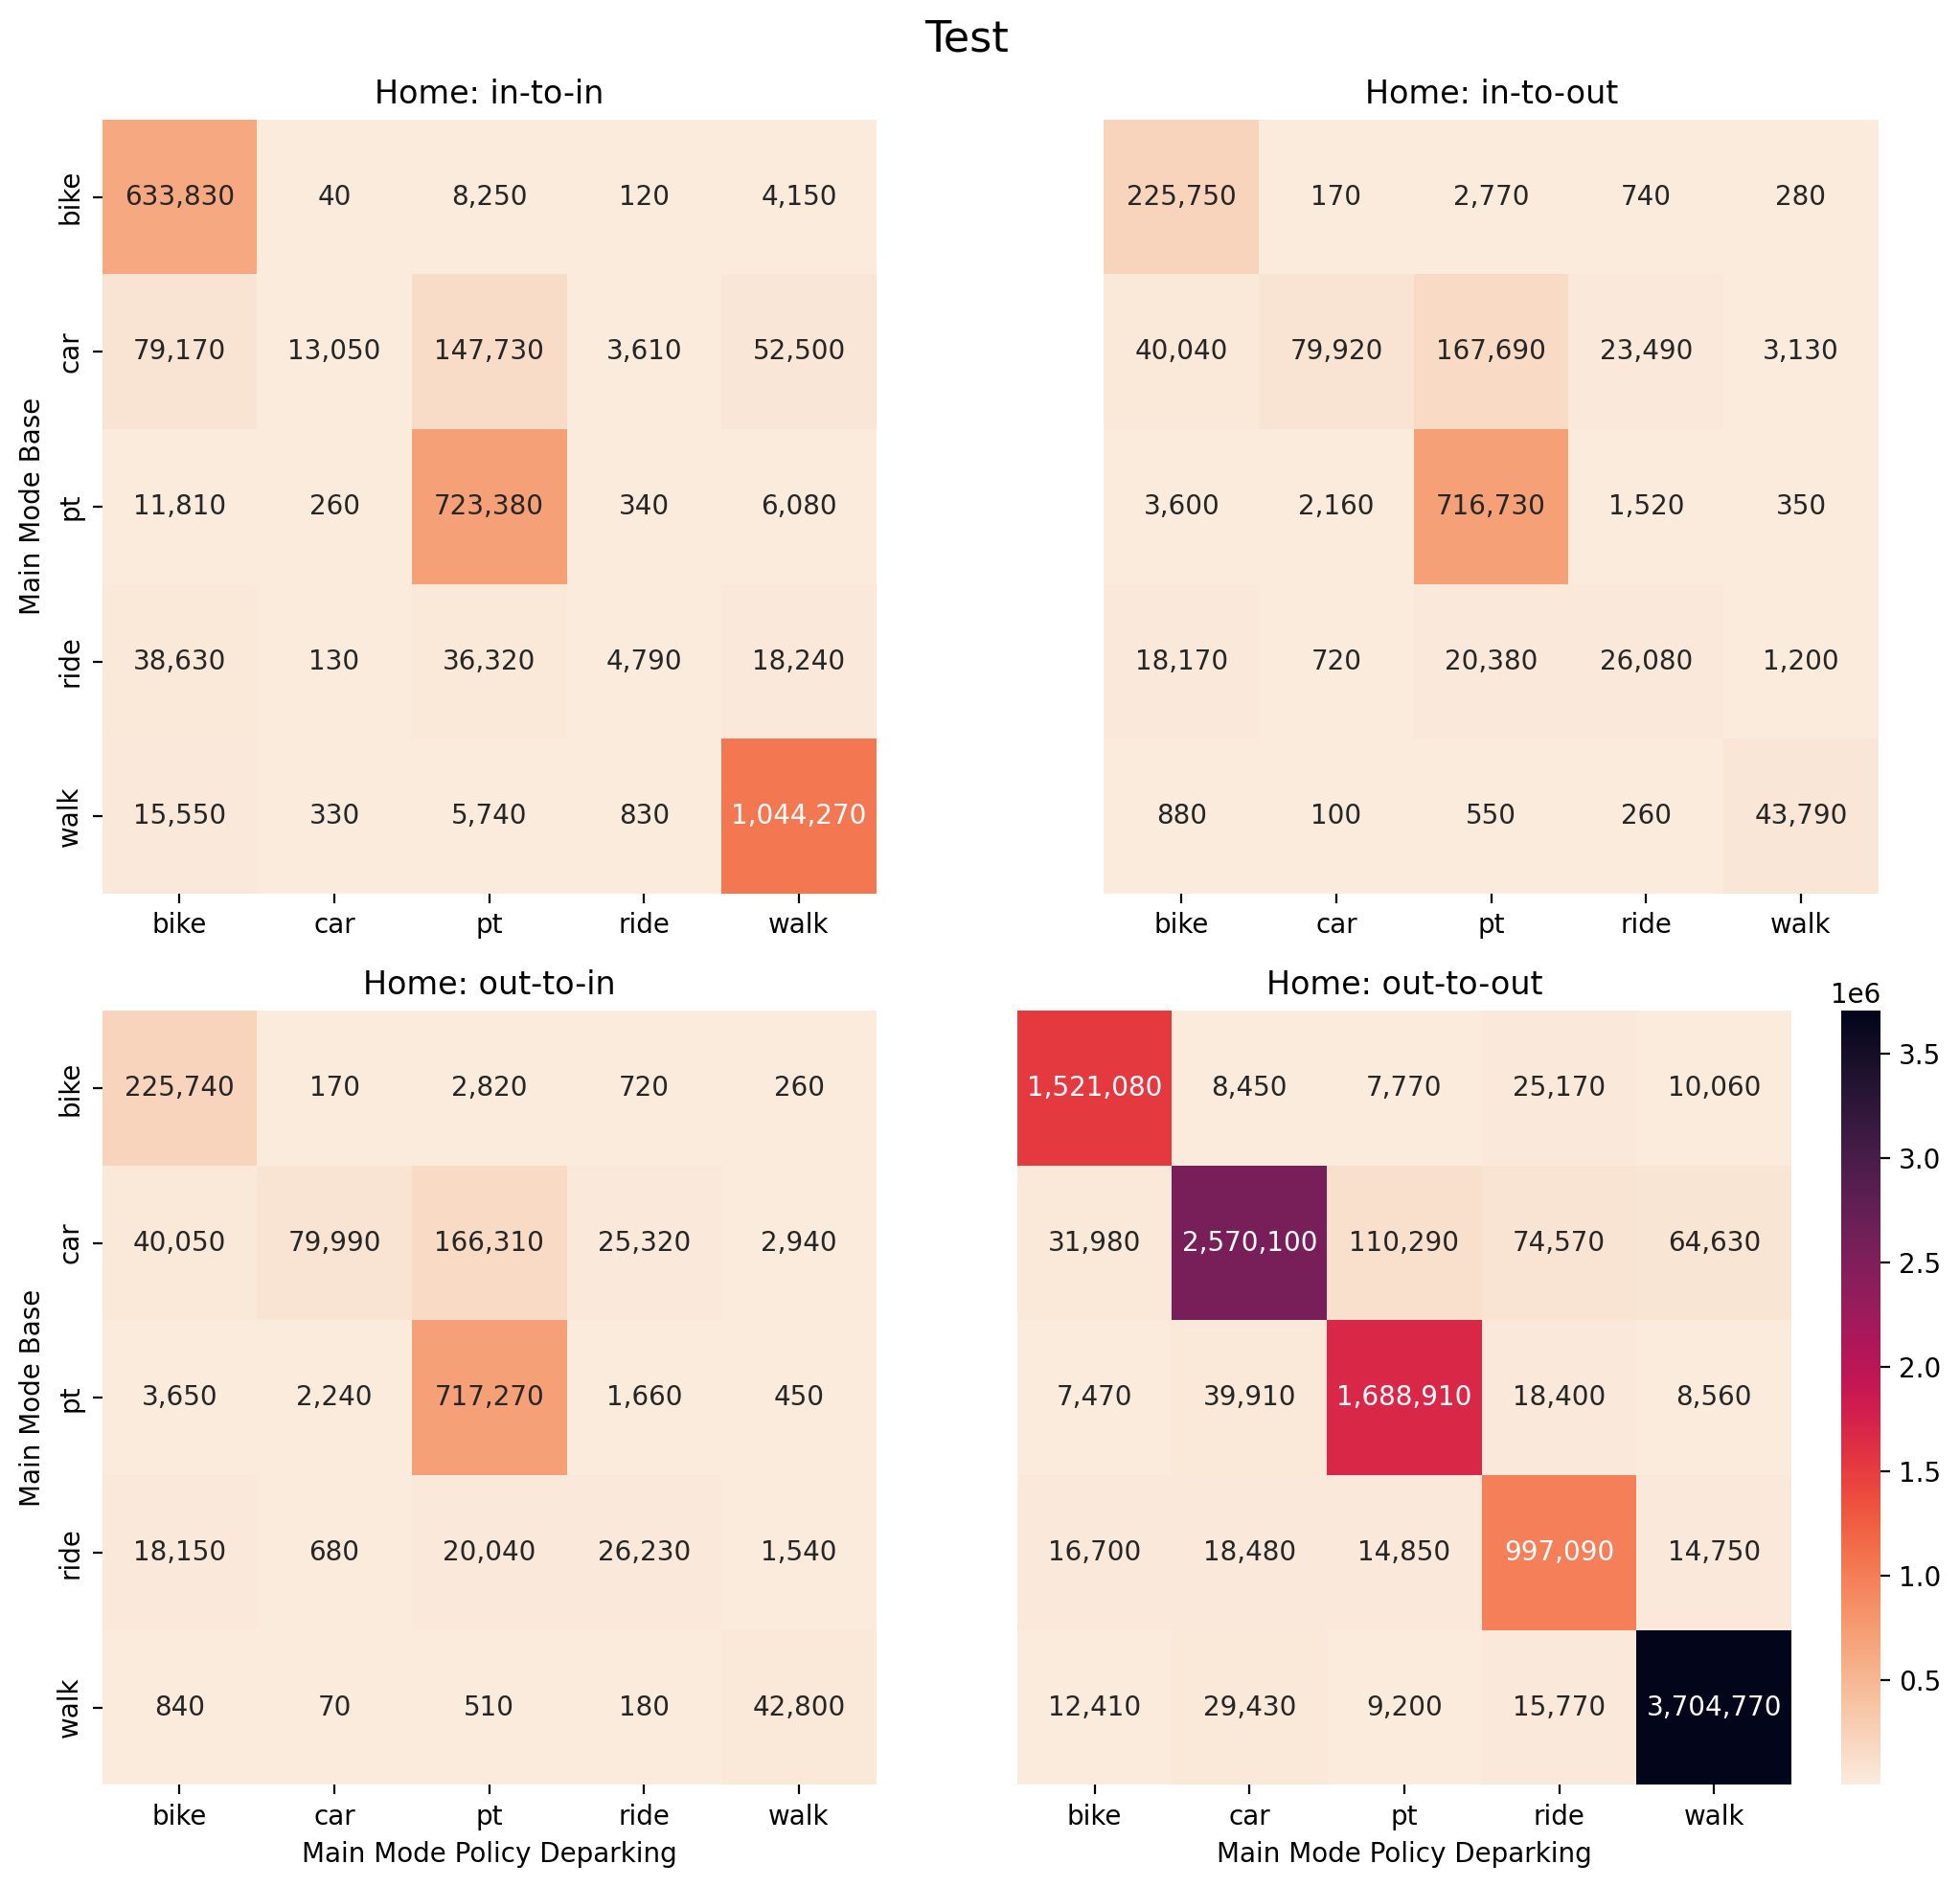

In [263]:
plot_mode_combination_heatmap_facet(mode_combination_matrix_direction(in_out_trips_deparking), value_col="trip_count", title= "Test", cmap="rocket_r", cluster_col="direction", center=False)

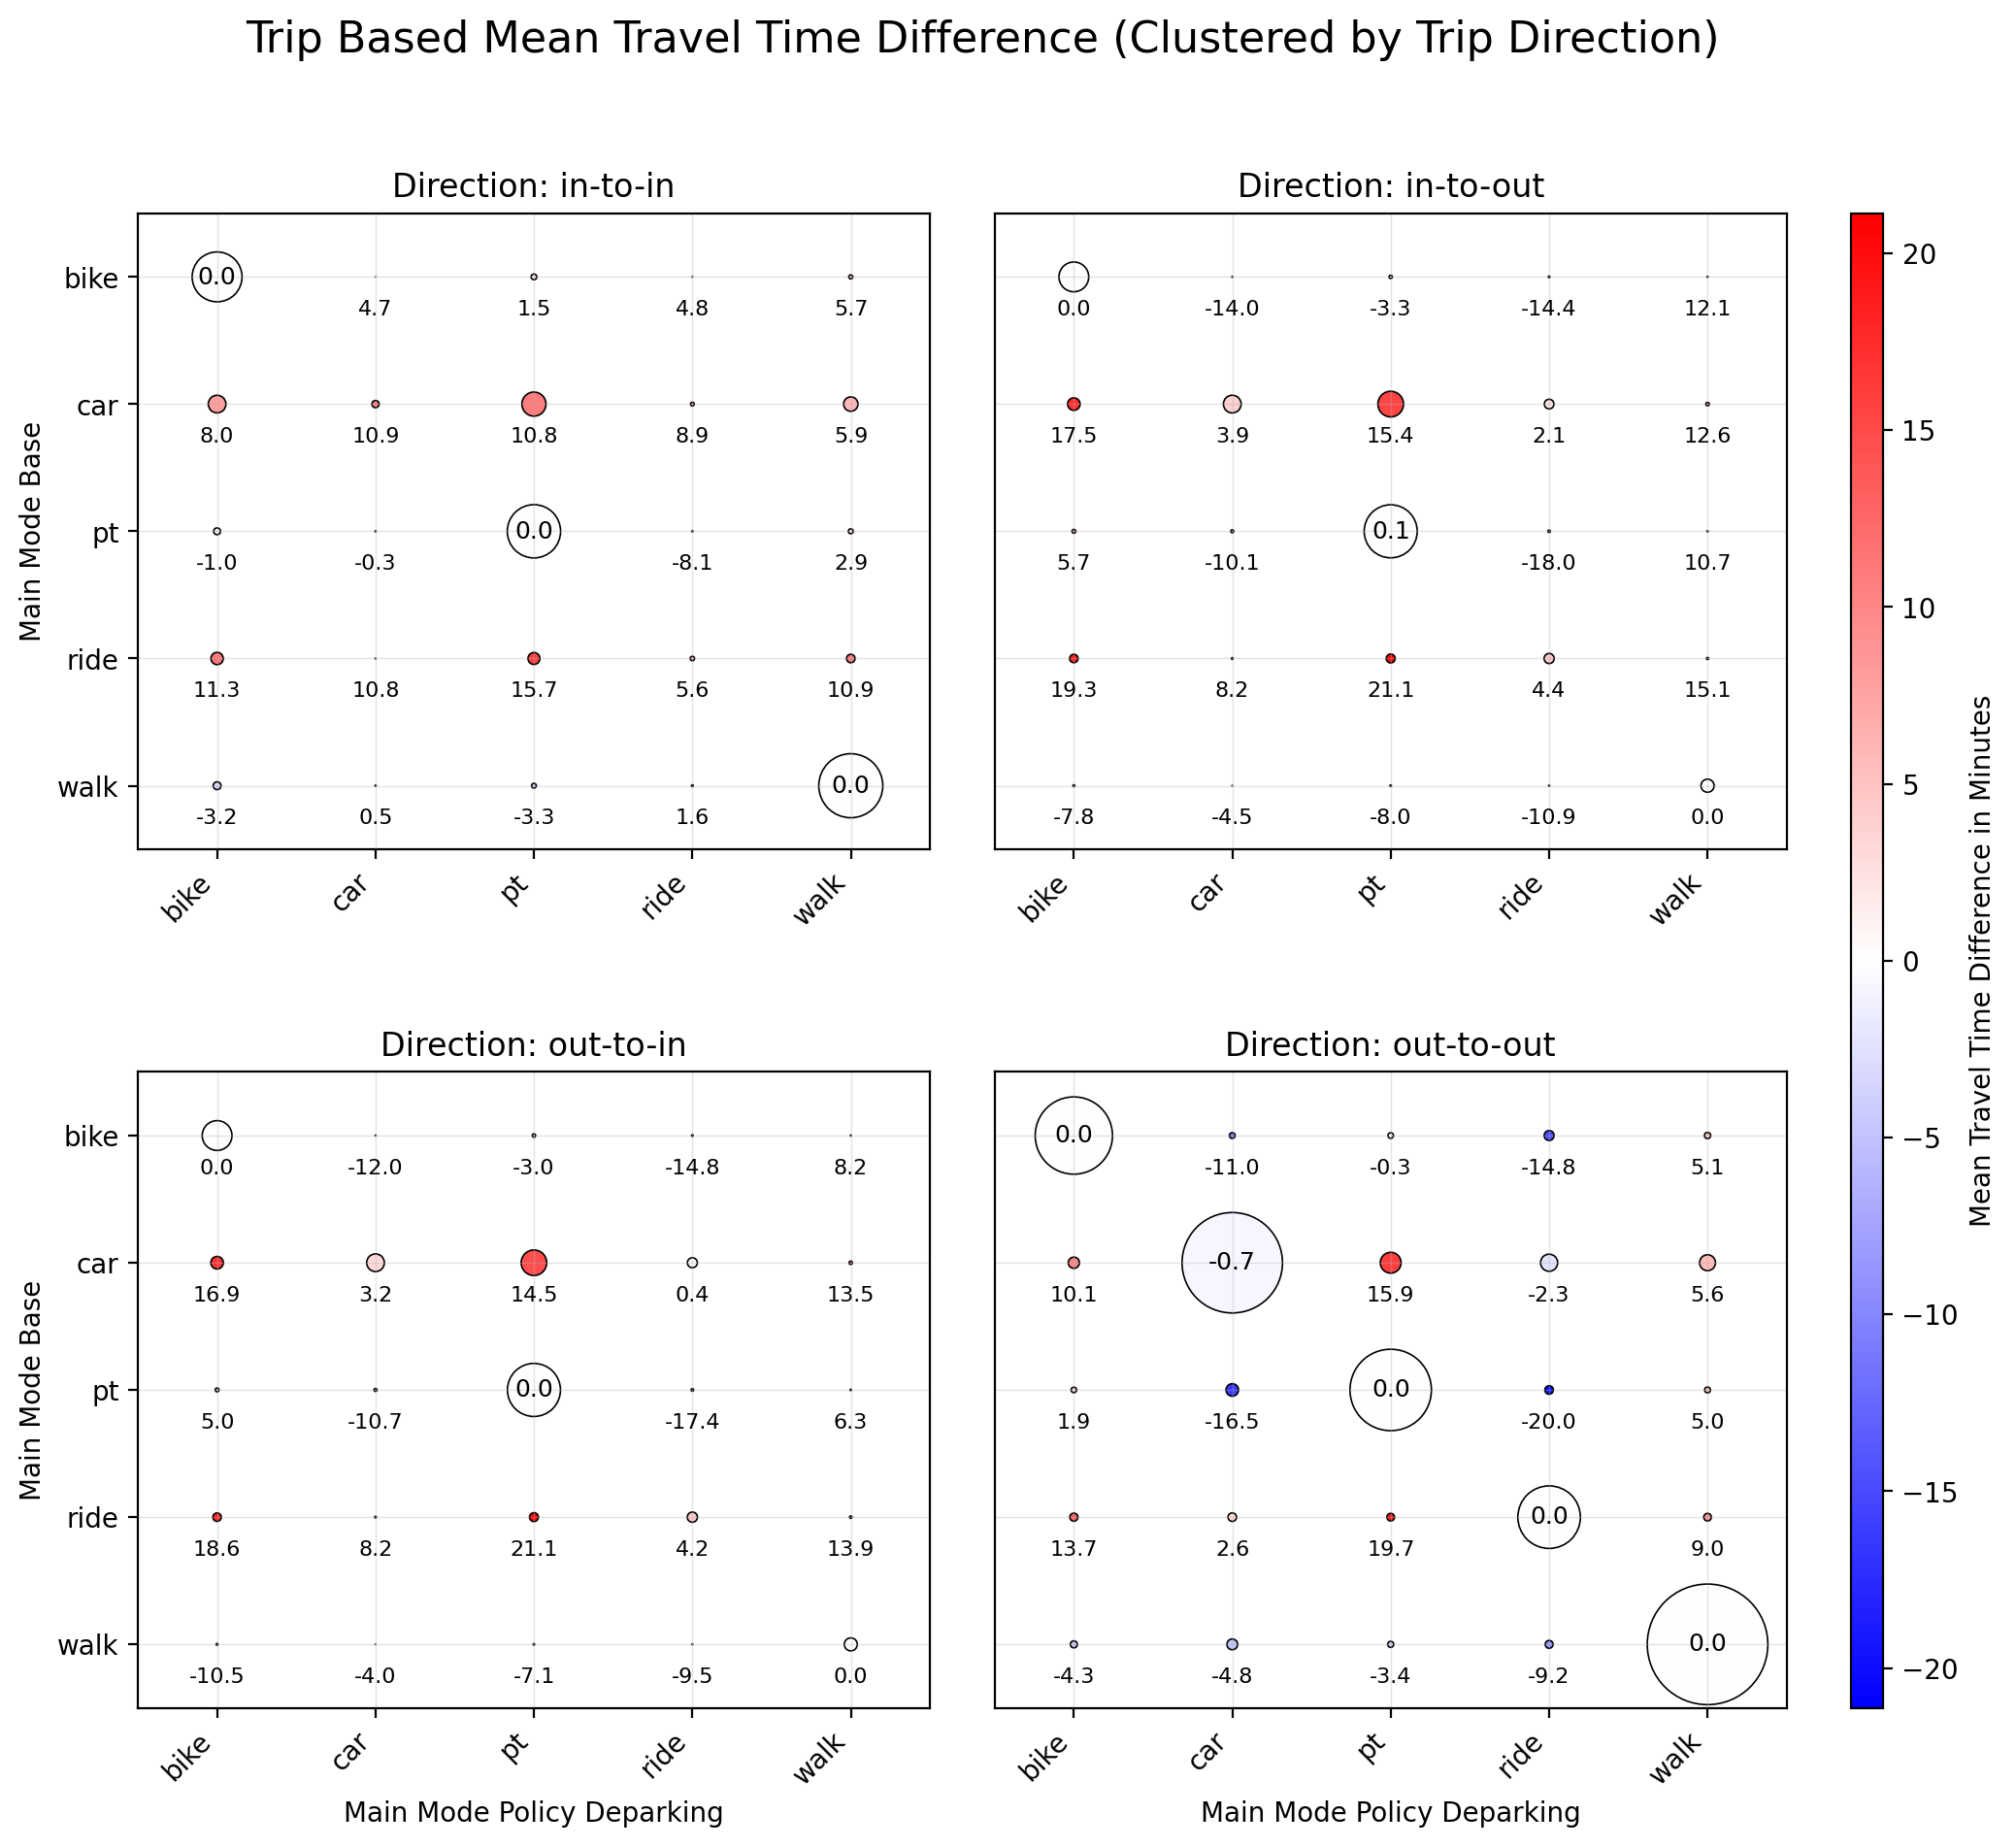

In [254]:
plot_mode_combination_bubble_facet(mode_combination_matrix_direction(in_out_trips_deparking), "Trip Based Mean Travel Time Difference (Clustered by Trip Direction)", cluster_col="direction", size_scale=2000, cluster_label="Direction")

# Investigation of newly introduced PT waiting time

In [294]:
base_x_policy_deparking_trips_home.columns

Index(['person_base', 'trip_number_base', 'trip_id', 'dep_time_base',
       'trav_time_base', 'wait_time_base', 'traveled_distance_base',
       'euclidean_distance_base', 'main_mode_base',
       'longest_distance_mode_base', 'modes_base', 'start_activity_type_base',
       'end_activity_type_base', 'start_facility_id_base', 'start_link_base',
       'start_x_base', 'start_y_base', 'end_facility_id_base', 'end_link_base',
       'end_x_base', 'end_y_base', 'first_pt_boarding_stop_base',
       'last_pt_egress_stop_base', 'person_policy', 'trip_number_policy',
       'dep_time_policy', 'trav_time_policy', 'wait_time_policy',
       'traveled_distance_policy', 'euclidean_distance_policy',
       'main_mode_policy', 'longest_distance_mode_policy', 'modes_policy',
       'start_activity_type_policy', 'end_activity_type_policy',
       'start_facility_id_policy', 'start_link_policy', 'start_x_policy',
       'start_y_policy', 'end_facility_id_policy', 'end_link_policy',
       'end_x_poli

In [327]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_wait_time(df):
    filtered = df[
        (df["main_mode_base"] == "car") &
        (df["main_mode_policy"] == "pt") &
        (df["cluster"].isin(["Inner Ring", "Outer Ring"]))
        ].copy()

    filtered["wait_time_policy_min"] = (
            pd.to_timedelta(filtered["wait_time_policy"])
            .dt.total_seconds()
            / 60
    )

    filtered["cluster"] = filtered["cluster"].astype(str)

    ax = sns.ecdfplot(
        data=filtered,
        x="wait_time_policy_min",
        hue="cluster"
    )

    # Add mean and median lines for each cluster
    palette = sns.color_palette()

    for i, cluster in enumerate(["Inner Ring", "Outer Ring"]):
        values = filtered.loc[
            filtered["cluster"] == cluster,
            "wait_time_policy_min"
        ]

        mean = values.mean()
        median = values.median()

        color = palette[i]

        ax.axvline(
            mean,
            color=color,
            linestyle="--",
            alpha=0.8,
            linewidth=1.5,
            label=f"{cluster} mean ({mean:.1f} min)"
        )

        ax.axvline(
            median,
            color=color,
            linestyle=":",
            alpha=0.8,
            linewidth=1.5,
            label=f"{cluster} median ({median:.1f} min)"
        )

    # rebuild legend with the new entries
    ax.legend(title="Home location")

    # ax.legend_.set_title("Home location")

    plt.xlabel("Wait time (minutes)")
    plt.ylabel("Cumulative share of trips")
    title = "Distribution of PT Wait Times for Car → PT Switchers"
    plt.title(title)
    plt.xlim(0, filtered["wait_time_policy_min"].quantile(0.99))
    plt.tight_layout()
    plt.grid(True, which="major", linestyle="--", alpha=0.5)
    plt.savefig(
        "./plots/" + title + ".pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0
    )
    plt.show()

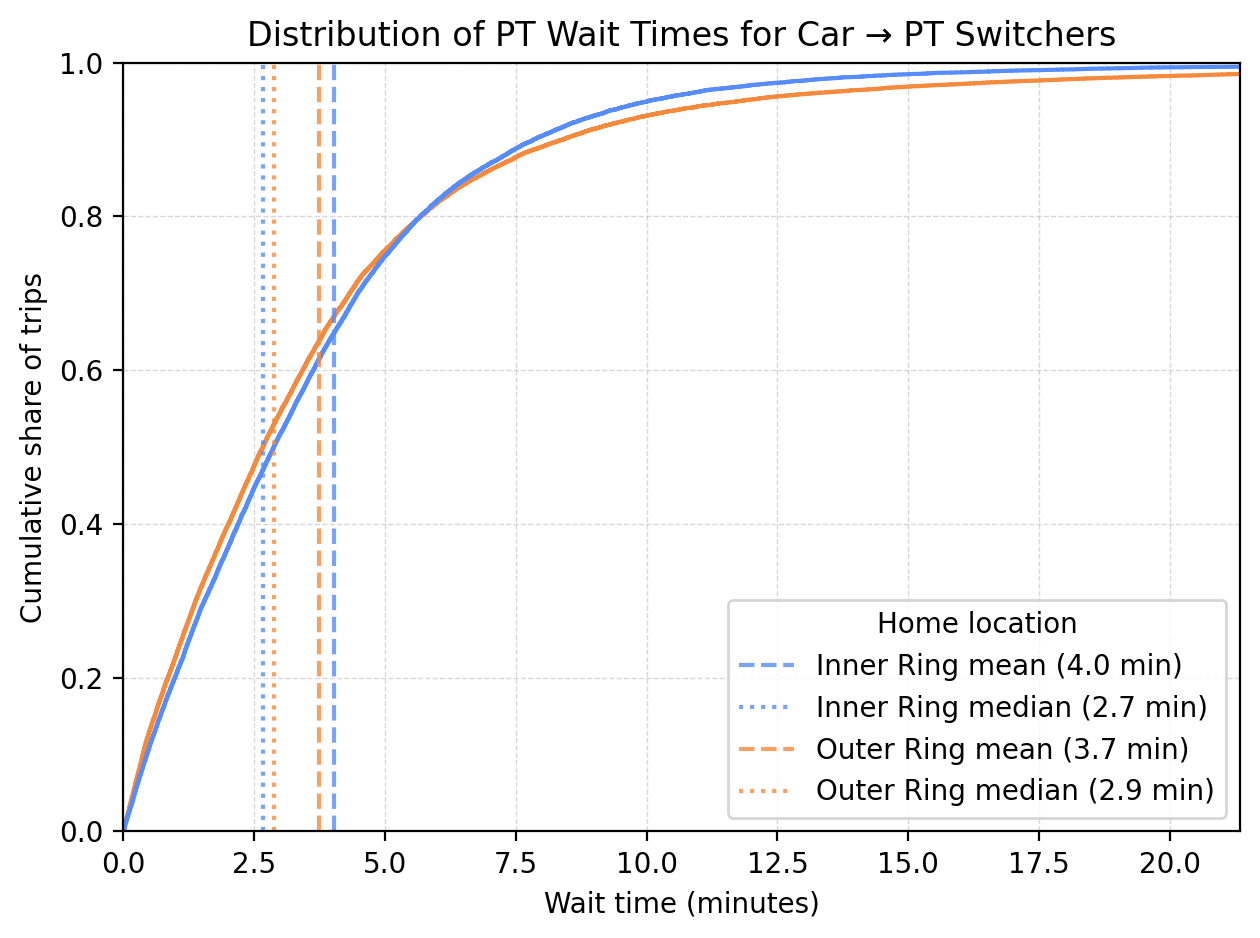

In [328]:
plot_wait_time(base_x_policy_deparking_trips_home)